In [157]:
#import libraries

In [158]:
from bs4 import BeautifulSoup

In [159]:
import requests

In [160]:
import time

In [161]:
import datetime

In [162]:
import pandas as pd

In [163]:
import matplotlib.pyplot as plt

In [164]:
#connect to website and pull in data
base_url = "https://api.results.scc-events.com/result"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36", "Accept-Encoding":"gzip, deflate", "Accept":"text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "DNT":"1","Connection":"close", "Upgrade-Insecure-Requests":"1"}

years = [year for year in range(2015, 2026) if year !=2020]
top100_results = []

for year in years:
    print(f"Collecting top 100 for {year}")

    if year < 2020:
        ci_value = "MAL"
    else:
        ci_value = "BML"

    collected = 0
    start = 0
    draw = 1

    while collected < 100:
        
        params = {
                "ek": "BM",
                "ci": ci_value,
                "y": str(year),
                "t": f"BM_{year}",
                "draw": draw,
                "start": start,
                "length": 20,
                "order[0][column]": 0,
                "order[0][dir]": "asc",
                "columns[0][data]": "platz",
                "columns[0][orderable]": "true"

        }
        page = requests.get(base_url, params=params, headers=headers)
        data = page.json()
        results = data["data"]

        if not results:
            break
            
        for runner in results:
            top100_results.append({
                "Event_Year": year,
                "Name": runner.get("name"),
                "Place": runner.get("platz"),
                "Gender": runner.get("sex"),
                "Gender_Place": runner.get("sex_platz"),
                "Club": runner.get("verein"),
                "Time": runner.get("brutto"),
                "Age": runner.get("ak"),
                "Nationality": runner.get("nation")
            })

        collected += len(results)
        start += 20
        draw + 1

        time.sleep(0.5)

df_top100 = pd.DataFrame(top100_results)
df_top100.head()

,Event_Year,Name,Place,Gender,Gender_Place,Club,Time,Age,Nationality
0,2015,"Kipchoge, Eliud",1,M,1,Kenia,02:04:00,30,KEN
1,2015,"Kiptanui, Eliud",2,M,2,Kenia,02:05:21,H,KEN
2,2015,"Lilesa, Feyisa",3,M,3,Äthiopien,02:06:57,H,ETH
3,2015,"Mutai, Emmanuel",4,M,4,Kenia,02:07:46,30,KEN
4,2015,"Mutai, Geoffrey",5,M,5,Kenia,02:09:29,30,KEN


In [165]:
#checking the corretness of the size of the data set
df_top100.groupby("Event_Year").size()

Event_Year
2015    100
2016    100
2017    100
2018    100
2019    100
2021    100
2022    100
2023    100
2024    100
2025    100
dtype: int64

In [166]:
#checking the data types
df_top100.dtypes

Event_Year       int64
Name            object
Place            int64
Gender          object
Gender_Place     int64
Club            object
Time            object
Age             object
Nationality     object
dtype: object

In [167]:
#converting 'Time' to int and converting time to seconds for further calculations
def time_to_seconds(t):
    h, m, s = map(int, t.split(":"))
    return h*3600 + m*60 + s
df_top100["Time_seconds"] = df_top100["Time"].apply(time_to_seconds)

Event_Year
2015    8370.55
2016    8572.22
2017    8445.55
2018    8546.08
2019    8187.64
2021    8699.29
2022    8290.88
2023    8131.90
2024    8112.53
2025    8433.88
Name: Time_seconds, dtype: float64
Event_Year
2015    02:19:30
2016    02:22:52
2017    02:20:45
2018    02:22:26
2019    02:16:27
2021    02:24:59
2022    02:18:10
2023    02:15:31
2024    02:15:12
2025    02:20:33
Name: Time_seconds, dtype: object


<Axes: title={'center': 'Average Top 100 Finishing Time'}, xlabel='Event Year', ylabel='Average Finishing Time in Seconds'>

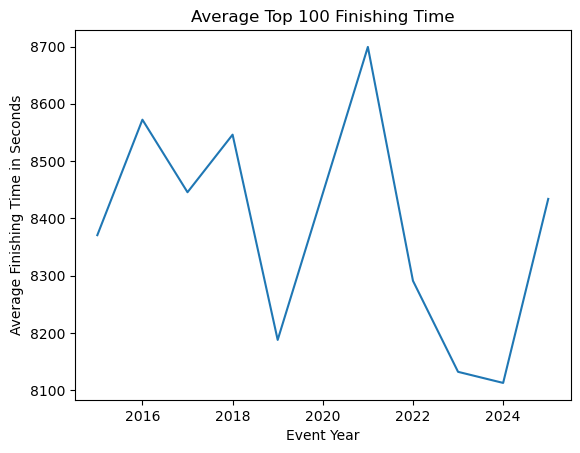

In [168]:
#calculating the average finishing time per year, converting back to Hours-Minutes-Seconds format and visualizing the results
avg_times = df_top100.groupby("Event_Year")["Time_seconds"].mean()
print(avg_times)
def seconds_to_time(sec):
    h = int(sec // 3600)
    m = int((sec % 3600) // 60)
    s = int(sec % 60)
    return f"{h:02}:{m:02}:{s:02}"
avg_times_formatted = avg_times.apply(seconds_to_time)
print(avg_times_formatted)
avg_times.plot(title= "Average Top 100 Finishing Time", xlabel= "Event Year", ylabel= "Average Finishing Time in Seconds")

In [169]:
#calculating the average finishing time overall for each gender
df_top100.groupby("Gender")["Time_seconds"].mean()

Gender
M    8360.568433
W    8557.202128
Name: Time_seconds, dtype: float64

Gender  Event_Year
M       2015          8363.208333
        2016          8560.351064
        2017          8434.478723
        2018          8540.460674
        2019          8172.957895
        2021          8692.191011
        2022          8241.926829
        2023          8097.045455
        2024          8088.119565
        2025          8410.011494
W       2015          8546.750000
        2016          8758.166667
        2017          8619.000000
        2018          8591.545455
        2019          8466.600000
        2021          8756.727273
        2022          8513.888889
        2023          8387.500000
        2024          8393.250000
        2025          8593.615385
Name: Time_seconds, dtype: float64


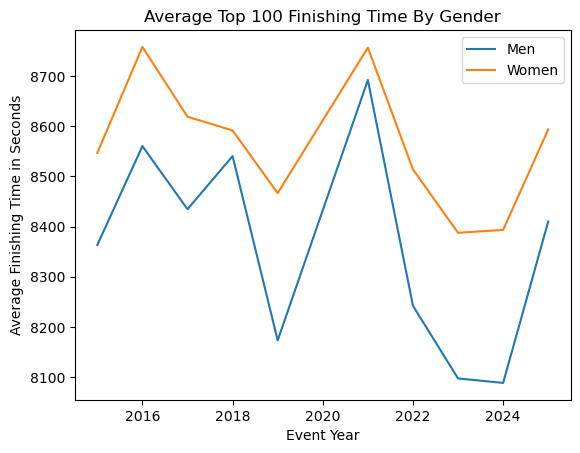

In [170]:
#calculating the average finishing time for each gender for every year
avg_times_gender = df_top100.groupby(["Gender", "Event_Year"])["Time_seconds"].mean()
print(avg_times_gender)
male_avg_time = avg_times_gender.loc["M"]
female_avg_time = avg_times_gender.loc["W"]
male_avg_time.plot(label="Men", title = "Average Top 100 Finishing Time By Gender", xlabel="Event Year", ylabel="Average Finishing Time in Seconds")
female_avg_time.plot(label="Women", title = "Average Top 100 Finishing Time By Gender", xlabel="Event Year")
plt.legend()

Gender       M   W
Event_Year        
2015        96   4
2016        94   6
2017        94   6
2018        89  11
2019        95   5
2021        89  11
2022        82  18
2023        88  12
2024        92   8
2025        87  13


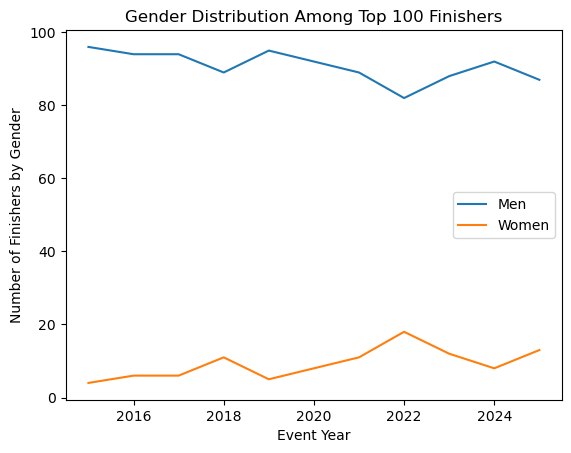

In [171]:
#calculating and visualizing the gender distribution among the top 100 finishers
gender_counts = (df_top100.groupby(["Event_Year", "Gender"]).size().unstack())
print(gender_counts)
gender_counts["M"].plot(label="Men", title="Gender Distribution Among Top 100 Finishers", xlabel="Event Year", ylabel="Number of Finishers by Gender")
gender_counts["W"].plot(label="Women", title="Gender Distribution Among Top 100 Finishers", xlabel="Event Year", ylabel="Number of Finishers by Gender")
plt.legend()

Event_Year
2015    7440
2016    7383
2017    7412
2018    7299
2019    7301
2021    7545
2022    7269
2023    7362
2024    7397
2025    7336
Name: Time_seconds, dtype: int64


<Axes: title={'center': 'Fastes Time Per Year'}, xlabel='Event Year', ylabel='Time in Seconds'>

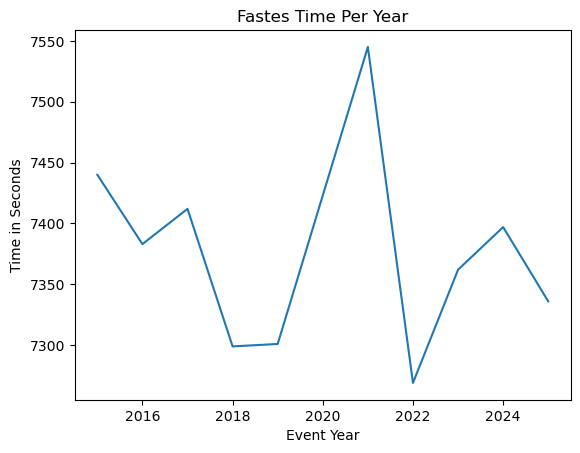

In [172]:
#calculating and visualizing the fastest finishing times
fastest_time = df_top100.groupby("Event_Year")["Time_seconds"].min()
print(fastest_time)
fastest_time.plot(title = "Fastes Time Per Year", xlabel= "Event Year", ylabel = "Time in Seconds")

In [173]:
#calculating the nationalities distribution of the top 100 finishers
country_counts = (df_top100.groupby(["Event_Year", "Nationality"]).size())
top3_countries = (country_counts.groupby(level=0).nlargest(3))
print(top3_countries)

Event_Year  Event_Year  Nationality
2015        2015        GBR            14
                        IRL            11
                        DEU             7
2016        2016        DEU            13
                        KEN            11
                        ETH             9
2017        2017        GBR            13
                        GER            11
                        AUS             8
2018        2018        GBR            10
                        JPN             9
                        USA             9
2019        2019        USA            11
                        ETH             7
                        CHN             6
2021        2021        GER            15
                        GBR            10
                        ETH             9
2022        2022        JPN            20
                        USA            12
                        KEN            11
2023        2023        ETH            16
                        KEN            1

In [174]:
#calculating the age group distribution of the top 100 finishers
age_count = (df_top100.groupby(["Event_Year", "Age"]).size())
top3_age_distribution = (age_count.groupby(level=0).nlargest(3))
print(top3_age_distribution)

Event_Year  Event_Year  Age
2015        2015        H      40
                        30     34
                        35     21
2016        2016        30     33
                        H      30
                        35     25
2017        2017        H      45
                        30     31
                        35     16
2018        2018        H      37
                        30     33
                        35     17
2019        2019        30     43
                        H      36
                        35     16
2021        2021        30     31
                        H      29
                        35     22
2022        2022        H      42
                        30     34
                        35     18
2023        2023        H      40
                        30     34
                        35     19
2024        2024        H      42
                        30     41
                        35     14
2025        2025        H      44
                    